# 3.3 — Mean-Variance Loss & CORAL pour l'estimation d'âge apparent

**Dataset** : APPA-real (4113 train / 1500 valid / 1978 test)  
**Backbone** : SE-ResNeXt50-32x4d pré-entraîné ImageNet  
**Environnement cible** : Google Colab T4 (ou macOS local)

---

## Contexte

Le notebook `3_Label_smoothing_improved.ipynb` atteint un MAE d'environ **6.3 ans** avec Label Smoothing gaussien (σ=3.0).  
Ce notebook explore deux méthodes complémentaires :

| # | Méthode | Idée clé | Avantage |
|---|---|---|---|
| 9.1 | **Mean-Variance Loss** (Pan et al., CVPR 2018) | Régularise μ et σ² de la distribution prédite | Prédiction et calibration apprises conjointement |
| 9.2 | **CORAL** (Cao et al., PRL 2020) | K−1 classifieurs binaires avec poids partagés | Cohérence ordinale garantie par construction |

Les deux méthodes utilisent la **même architecture backbone** (SE-ResNeXt50) et le **même dataset** (APPA-real avec crop facial), seule la tête et la loss changent.

In [1]:
# ── Environnement & imports ───────────────────────────────────────────────────
import os, sys, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Détection Colab / Local ───────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_DIR = Path('/content/drive/MyDrive/Deep-learning-project')
    os.chdir(PROJECT_DIR)
else:
    PROJECT_DIR = Path('/Users/louisduvignacq/Desktop/X/3A/Deep learning/Deep-learning-project')
    os.chdir(PROJECT_DIR)

sys.path.insert(0, str(PROJECT_DIR))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print(f"Environnement : {'Google Colab' if IN_COLAB else 'Local macOS'}")
print(f"PROJECT_DIR   : {PROJECT_DIR}")
print(f"Device        : {device}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} Go")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environnement : Google Colab
PROJECT_DIR   : /content/drive/MyDrive/Deep-learning-project
Device        : cuda
Environnement : Google Colab
PROJECT_DIR   : /content/drive/MyDrive/Deep-learning-project
Device        : cuda
GPU           : Tesla T4
VRAM          : 14.6 Go
GPU           : Tesla T4
VRAM          : 14.6 Go


In [2]:
# ── Extraction dataset depuis Drive (Colab uniquement) ────────────────────────
# Sur macOS local : sauter cette cellule, DATA_ROOT sera défini plus bas.

if IN_COLAB:
    import shutil, zipfile

    zip_path   = '/content/drive/MyDrive/appa-real-release.zip'
    local_zip  = '/content/appa-real-release.zip'
    local_data = Path('/content/appa-real-release')

    if not Path(zip_path).exists():
        print(f"❌ Fichier non trouvé : {zip_path}")
        print("   Uploadez appa-real-release.zip dans 'Mon Drive' sur Google Drive.")
    else:
        if not local_data.exists():
            print("📦 Copie du zip depuis Drive vers /content/ ...")
            shutil.copy(zip_path, local_zip)
            print("📂 Extraction en cours ...")
            with zipfile.ZipFile(local_zip, 'r') as z:
                z.extractall('/content/')
            os.remove(local_zip)
            macosx = Path('/content/__MACOSX')
            if macosx.exists():
                shutil.rmtree(macosx)
            print("✅ Dataset extrait dans /content/appa-real-release/")
        else:
            print("✅ Dataset déjà présent (skip extraction)")

        DATA_ROOT = local_data
        for split in ['train', 'valid', 'test']:
            d = local_data / split
            n = len([f for f in d.iterdir() if f.suffix == '.jpg' and '_face' not in f.name]) if d.exists() else 0
            print(f"   {split:6s} : {n} images")

📦 Copie du zip depuis Drive vers /content/ ...
📂 Extraction en cours ...
📂 Extraction en cours ...
✅ Dataset extrait dans /content/appa-real-release/
   train  : 4113 images
   valid  : 1500 images
   test   : 1978 images
✅ Dataset extrait dans /content/appa-real-release/
   train  : 4113 images
   valid  : 1500 images
   test   : 1978 images


In [3]:
# ── Dataset APPA-real ─────────────────────────────────────────────────────────
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

class AgeDataset(Dataset):
    """
    Retourne : (image, age_class, age_float, real_age, std)
    Utilise le crop facial (_face.jpg) quand disponible.
    """
    def __init__(self, csv_path, img_dir, transform=None, num_classes=101):
        self.img_dir     = Path(img_dir).resolve()
        self.transform   = transform
        self.num_classes = num_classes

        df = pd.read_csv(csv_path)
        df = df[df['file_name'].apply(lambda x: (self.img_dir / x).exists())].reset_index(drop=True)
        self.df      = df
        self.age_col = 'apparent_age_avg' if 'apparent_age_avg' in df.columns else 'apparent_age'

        n_face = df['file_name'].apply(lambda x: (self.img_dir / (x + '_face.jpg')).exists()).sum()
        print(f"   {self.img_dir.name} : {len(df)} images ({n_face} crops faciaux)")

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        age      = float(row[self.age_col])
        real_age = float(row['real_age']) if 'real_age' in self.df.columns else age
        std      = float(row['apparent_age_std']) if 'apparent_age_std' in self.df.columns else 2.0

        face_path = self.img_dir / (row['file_name'] + '_face.jpg')
        full_path = self.img_dir / row['file_name']
        img_path  = face_path if face_path.exists() else full_path

        img = cv2.imread(str(img_path))
        img = np.zeros((224, 224, 3), dtype=np.uint8) if img is None else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']

        age_class = max(0, min(self.num_classes - 1, int(round(age))))
        return img, age_class, age, real_age, std


train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-20, 20), p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
valid_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── Dataloaders ───────────────────────────────────────────────────────────────
if 'DATA_ROOT' not in dir() or not Path(DATA_ROOT).exists():
    DATA_ROOT = PROJECT_DIR / 'appa-real-release'
DATA_ROOT   = Path(DATA_ROOT)
CSV_ROOT    = PROJECT_DIR / 'appa-real-release'
NUM_CLASSES = 101
BATCH_SIZE  = 64
NUM_WORKERS = 2 if IN_COLAB else 0
PIN_MEMORY  = IN_COLAB

print(f"DATA_ROOT : {DATA_ROOT}")
print("Chargement APPA-REAL :")
train_ds = AgeDataset(CSV_ROOT / 'gt_avg_train.csv', DATA_ROOT / 'train', train_transform)
valid_ds = AgeDataset(CSV_ROOT / 'gt_avg_valid.csv', DATA_ROOT / 'valid', valid_transform)
test_ds  = AgeDataset(CSV_ROOT / 'gt_avg_test.csv',  DATA_ROOT / 'test',  valid_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
print(f"\nTrain : {len(train_ds)} | Valid : {len(valid_ds)} | Test : {len(test_ds)}")

DATA_ROOT : /content/appa-real-release
Chargement APPA-REAL :
   train : 4113 images (4113 crops faciaux)
   train : 4113 images (4113 crops faciaux)
   valid : 1500 images (1500 crops faciaux)
   valid : 1500 images (1500 crops faciaux)
   test : 1978 images (1978 crops faciaux)

Train : 4113 | Valid : 1500 | Test : 1978
   test : 1978 images (1978 crops faciaux)

Train : 4113 | Valid : 1500 | Test : 1978


── TRAIN ──────────────────────────────────────
  Lignes CSV            : 4113
  Images disque (.jpg)  : 4113  (dont 4113 _face)
  Âge apparent moyen    : 30.19 ans
  Âge apparent médian   : 28.07 ans
  Âge min / max         : 0.9 / 89.2 ans
  Distrib < 10 ans      : 366  |  > 60 ans : 151

── VALID ──────────────────────────────────────
  Lignes CSV            : 1500
  Images disque (.jpg)  : 1500  (dont 1500 _face)
  Âge apparent moyen    : 30.29 ans
  Âge apparent médian   : 28.20 ans
  Âge min / max         : 0.9 / 87.9 ans
  Distrib < 10 ans      : 125  |  > 60 ans : 60

── TEST ──────────────────────────────────────
  Lignes CSV            : 1978
  Images disque (.jpg)  : 1978  (dont 1978 _face)
  Âge apparent moyen    : 33.09 ans
  Âge apparent médian   : 30.63 ans
  Âge min / max         : 0.9 / 95.6 ans
  Distrib < 10 ans      : 222  |  > 60 ans : 175



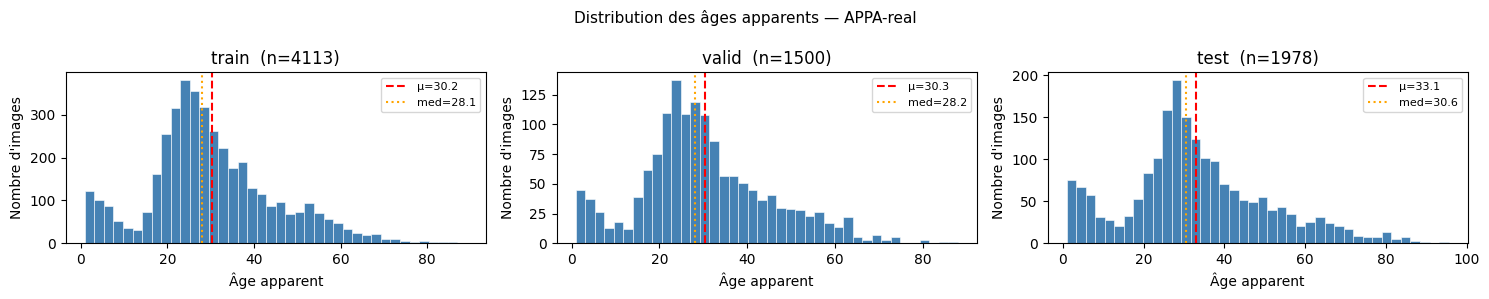

Vérification correspondance CSV ↔ disque :
  train  : 0 lignes CSV sans image correspondante sur disque
  valid  : 0 lignes CSV sans image correspondante sur disque
  test   : 0 lignes CSV sans image correspondante sur disque


In [16]:
# ── Diagnostic dataset ────────────────────────────────────────────────────────
import pandas as pd

age_col = 'apparent_age_avg'

for split_name, ds in [('train', train_ds), ('valid', valid_ds), ('test', test_ds)]:
    ages = ds.df[age_col].values
    n_images_on_disk = len([
        f for f in (DATA_ROOT / split_name).iterdir()
        if f.suffix == '.jpg' and '_face' not in f.name
    ])
    n_face_on_disk = len([
        f for f in (DATA_ROOT / split_name).iterdir()
        if f.suffix == '.jpg' and '_face' in f.name
    ])
    print(f"── {split_name.upper()} ──────────────────────────────────────")
    print(f"  Lignes CSV            : {len(ds.df)}")
    print(f"  Images disque (.jpg)  : {n_images_on_disk}  (dont {n_face_on_disk} _face)")
    print(f"  Âge apparent moyen    : {ages.mean():.2f} ans")
    print(f"  Âge apparent médian   : {pd.Series(ages).median():.2f} ans")
    print(f"  Âge min / max         : {ages.min():.1f} / {ages.max():.1f} ans")
    print(f"  Distrib < 10 ans      : {(ages < 10).sum()}  |  > 60 ans : {(ages > 60).sum()}")
    print()

# Distribution visuelle
fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=False)
for ax, (split_name, ds) in zip(axes, [('train', train_ds), ('valid', valid_ds), ('test', test_ds)]):
    ax.hist(ds.df[age_col].values, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_title(f'{split_name}  (n={len(ds.df)})')
    ax.set_xlabel('Âge apparent')
    ax.set_ylabel('Nombre d\'images')
    ax.axvline(ds.df[age_col].mean(), color='red',    linestyle='--', label=f'μ={ds.df[age_col].mean():.1f}')
    ax.axvline(ds.df[age_col].median(), color='orange', linestyle=':',  label=f'med={ds.df[age_col].median():.1f}')
    ax.legend(fontsize=8)
plt.suptitle('Distribution des âges apparents — APPA-real', fontsize=11)
plt.tight_layout()
plt.show()

# Vérifie que les images existent bien pour chaque ligne du CSV
print("Vérification correspondance CSV ↔ disque :")
for split_name, ds in [('train', train_ds), ('valid', valid_ds), ('test', test_ds)]:
    missing = ds.df['file_name'].apply(
        lambda x: not (DATA_ROOT / split_name / x).exists()
    ).sum()
    print(f"  {split_name:6s} : {missing} lignes CSV sans image correspondante sur disque")


---

## Partie 1 — Mean-Variance Loss
*Pan et al., CVPR 2018*

### Principe

Au lieu d'imposer une distribution gaussienne cible fixée (comme dans le Label Smoothing), on laisse le réseau apprendre **librement** sa distribution $\mathbf{p} = \text{softmax}(\mathbf{z})$, mais on ajoute deux termes de régularisation :

$$\mathcal{L}_{\text{MV}} = \mathcal{L}_{\text{CE}} + \lambda_1 (\hat{\mu} - \mu^*)^2 + \lambda_2 \hat{\sigma}^2$$

- $\hat{\mu} = \sum_k k \cdot p_k$ — espérance prédite (= âge prédit via softmax expectation)
- $\hat{\sigma}^2 = \sum_k (k - \hat{\mu})^2 \cdot p_k$ — variance de la distribution prédite
- $\lambda_1 = 0.2$ pénalise l'erreur de moyenne
- $\lambda_2 = 0.05$ pénalise l'étalement excessif de la distribution

**Avantage clé** : pas de choix de σ, le réseau apprend conjointement *où* et *avec quelle confiance* prédire.

In [4]:
# ── Mean-Variance Loss ────────────────────────────────────────────────────────

class MeanVarianceLoss(nn.Module):
    """
    Pan et al., CVPR 2018.
    L = L_CE + lambda_mean * (mu_pred - mu_target)^2 + lambda_var * sigma_pred^2

    Paramètres :
        num_classes  : 101 (âges 0-100)
        lambda_mean  : poids erreur de moyenne       (défaut 0.2)
        lambda_var   : poids régularisation variance (défaut 0.05)
    """
    def __init__(self, num_classes: int = 101,
                 lambda_mean: float = 0.2,
                 lambda_var:  float = 0.05):
        super().__init__()
        self.lambda_mean = lambda_mean
        self.lambda_var  = lambda_var
        self.register_buffer('classes', torch.arange(num_classes, dtype=torch.float32))

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        logits  : (B, K) — logits bruts
        targets : (B,)   — âges cibles float
        """
        probs   = F.softmax(logits, dim=1)                              # (B, K)
        mu_pred = (probs * self.classes).sum(dim=1)                     # (B,)
        diff2   = self.classes.unsqueeze(0) - mu_pred.unsqueeze(1)      # (B, K)
        var_pred = (probs * diff2 ** 2).sum(dim=1)                      # (B,)

        # Cross-entropie standard (cible arrondie à l'entier)
        targets_int  = targets.long().clamp(0, self.classes.size(0) - 1)
        loss_ce      = F.cross_entropy(logits, targets_int)

        # Terme d'erreur de moyenne
        loss_mean = ((mu_pred - targets) ** 2).mean()

        # Terme de régularisation variance
        loss_var  = var_pred.mean()

        return loss_ce + self.lambda_mean * loss_mean + self.lambda_var * loss_var

    def predict_age(self, logits: torch.Tensor) -> torch.Tensor:
        """Espérance de la distribution softmax → âge continu (B,)."""
        probs = F.softmax(logits, dim=1)
        return (probs * self.classes).sum(dim=1)


In [6]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pretrainedmodels"], check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'pretrainedmodels'], returncode=0)

In [10]:
# ── Architecture : backbone SE-ResNeXt50 + tête MV ────────────────────────────
from model import get_model

class MVAgeHead(nn.Module):
    """Tête classique 2048 → 256 → 101 (identique au Label Smoothing)."""
    def __init__(self, embed_dim: int, num_classes: int = 101, dropout: float = 0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
        self.register_buffer('bins', torch.arange(num_classes, dtype=torch.float32))

    def forward(self, x): return self.head(x)

    def predict_age(self, logits):
        probs = F.softmax(logits, dim=-1)
        return (probs * self.bins).sum(dim=-1)


class MVAgeModel(nn.Module):
    def __init__(self, backbone, embed_dim, num_classes=101, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.flatten  = nn.Flatten(1)
        self.bn       = nn.BatchNorm1d(embed_dim)
        self.head     = MVAgeHead(embed_dim, num_classes, dropout)

    def forward(self, x):
        feat = self.flatten(self.backbone(x))
        return self.head(self.bn(feat))


# Instanciation
_base_mv             = get_model('se_resnext50_32x4d', num_classes=NUM_CLASSES, pretrained='imagenet')
embed_dim_mv         = _base_mv.last_linear.in_features
_base_mv.last_linear = nn.Identity()
model_mv             = MVAgeModel(_base_mv, embed_dim_mv, NUM_CLASSES).to(device)
criterion_mv         = MeanVarianceLoss(num_classes=NUM_CLASSES, lambda_mean=0.2, lambda_var=0.05).to(device)

# Vérification shapes
with torch.no_grad():
    _out = model_mv(torch.randn(2, 3, 224, 224).to(device))
    assert _out.shape == (2, NUM_CLASSES)
    print(f"✓ Forward MV : (2,3,224,224) → logits {_out.shape}")

total_mv     = sum(p.numel() for p in model_mv.parameters())
print(f"Paramètres total : {total_mv:,}")


✓ Forward MV : (2,3,224,224) → logits torch.Size([2, 101])
Paramètres total : 26,066,005


In [11]:
# ── Boucle d'entraînement — Mean-Variance Loss ────────────────────────────────

NUM_EPOCHS_MV    = 30
WARMUP_EPOCHS_MV = 5
CKPT_MV          = 'mv_loss_best.pth'

# Phase 1 : backbone gelé
for p in model_mv.backbone.parameters():
    p.requires_grad = False

optimizer_mv = torch.optim.AdamW([
    {'params': model_mv.bn.parameters(),   'lr': 1e-4},
    {'params': model_mv.head.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)
scheduler_mv = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_mv, T_max=WARMUP_EPOCHS_MV, eta_min=1e-5)

history_mv   = {'train_loss': [], 'train_mae': [], 'val_loss': [], 'val_mae': []}
best_mae_mv  = math.inf

print(f"{'Ep':>3} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7} | {'Mode':>12}")
print('-' * 72)

for epoch in range(1, NUM_EPOCHS_MV + 1):
    t0 = time.time()

    # Dégel backbone après warmup
    if epoch == WARMUP_EPOCHS_MV + 1:
        for p in model_mv.backbone.parameters():
            p.requires_grad = True
        optimizer_mv = torch.optim.AdamW([
            {'params': model_mv.backbone.parameters(), 'lr': 1e-5},
            {'params': model_mv.bn.parameters(),       'lr': 1e-4},
            {'params': model_mv.head.parameters(),     'lr': 1e-4},
        ], weight_decay=1e-4)
        scheduler_mv = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_mv, T_max=NUM_EPOCHS_MV - WARMUP_EPOCHS_MV, eta_min=1e-6)
        print(f'      → Backbone dégelé')

    # ── Train ─────────────────────────────────────────────────────────────────
    model_mv.train()
    tl, tm, n = 0.0, 0.0, 0
    for imgs, _, age_float, _, _ in train_loader:
        imgs      = imgs.to(device, non_blocking=True)
        age_float = age_float.to(device, dtype=torch.float32)
        optimizer_mv.zero_grad()
        logits = model_mv(imgs)
        loss   = criterion_mv(logits, age_float)
        loss.backward()
        optimizer_mv.step()
        with torch.no_grad():
            preds = criterion_mv.predict_age(logits)
            mae   = (preds - age_float).abs().sum()
        bs  = imgs.size(0)
        tl += loss.item() * bs;  tm += mae.item();  n += bs
    train_loss_mv, train_mae_mv = tl / n, tm / n

    # ── Validation ────────────────────────────────────────────────────────────
    model_mv.eval()
    vl, vm, n = 0.0, 0.0, 0
    with torch.no_grad():
        for imgs, _, age_float, _, _ in valid_loader:
            imgs      = imgs.to(device, non_blocking=True)
            age_float = age_float.to(device, dtype=torch.float32)
            logits    = model_mv(imgs)
            loss      = criterion_mv(logits, age_float)
            preds     = criterion_mv.predict_age(logits)
            mae       = (preds - age_float).abs().sum()
            bs = imgs.size(0)
            vl += loss.item() * bs;  vm += mae.item();  n += bs
    val_loss_mv, val_mae_mv = vl / n, vm / n

    scheduler_mv.step()
    history_mv['train_loss'].append(train_loss_mv)
    history_mv['train_mae'].append(train_mae_mv)
    history_mv['val_loss'].append(val_loss_mv)
    history_mv['val_mae'].append(val_mae_mv)

    mode = 'HEAD ONLY' if epoch <= WARMUP_EPOCHS_MV else 'FULL FT'
    print(f"{epoch:>3} | {train_loss_mv:>10.4f} | {train_mae_mv:>9.2f} | "
          f"{val_loss_mv:>8.4f} | {val_mae_mv:>7.2f}  ({time.time()-t0:.1f}s) | {mode:>12}")

    if val_mae_mv < best_mae_mv:
        best_mae_mv = val_mae_mv
        torch.save({'epoch': epoch, 'state_dict': model_mv.state_dict(),
                    'val_mae': val_mae_mv}, CKPT_MV)
        print(f'      ✓ Meilleur modèle MV sauvegardé (MAE={val_mae_mv:.2f})')

print(f"\n[Mean-Variance Loss] Meilleur Val MAE : {best_mae_mv:.2f} ans")

 Ep | Train Loss | Train MAE | Val Loss | Val MAE |         Mode
------------------------------------------------------------------------
  1 |   121.6702 |     16.81 |  83.2410 |   12.46  (30.8s) |    HEAD ONLY
  1 |   121.6702 |     16.81 |  83.2410 |   12.46  (30.8s) |    HEAD ONLY
      ✓ Meilleur modèle MV sauvegardé (MAE=12.46)
      ✓ Meilleur modèle MV sauvegardé (MAE=12.46)
  2 |    71.4479 |     10.78 |  61.6856 |    9.58  (29.0s) |    HEAD ONLY
  2 |    71.4479 |     10.78 |  61.6856 |    9.58  (29.0s) |    HEAD ONLY
      ✓ Meilleur modèle MV sauvegardé (MAE=9.58)
      ✓ Meilleur modèle MV sauvegardé (MAE=9.58)
  3 |    60.1287 |      9.51 |  56.2544 |    8.97  (30.6s) |    HEAD ONLY
  3 |    60.1287 |      9.51 |  56.2544 |    8.97  (30.6s) |    HEAD ONLY
      ✓ Meilleur modèle MV sauvegardé (MAE=8.97)
      ✓ Meilleur modèle MV sauvegardé (MAE=8.97)
  4 |    55.0036 |      9.02 |  53.5679 |    8.74  (30.9s) |    HEAD ONLY
  4 |    55.0036 |      9.02 |  53.5679 |    8.7

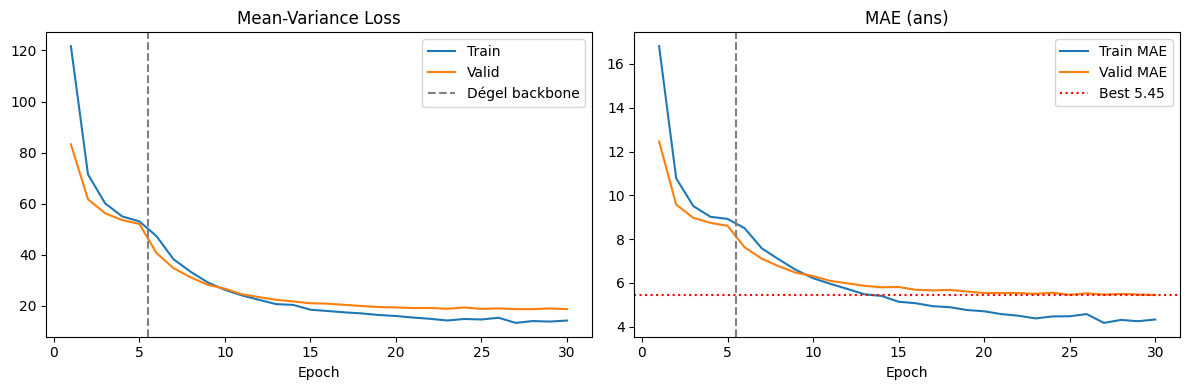

Meilleur Val MAE [MV] : 5.45 ans


In [12]:
# ── Courbes d'entraînement — MV Loss ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_r = range(1, NUM_EPOCHS_MV + 1)
ax1.plot(epochs_r, history_mv['train_loss'], label='Train')
ax1.plot(epochs_r, history_mv['val_loss'],   label='Valid')
ax1.axvline(WARMUP_EPOCHS_MV + 0.5, color='gray', linestyle='--', label='Dégel backbone')
ax1.set_title('Mean-Variance Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(epochs_r, history_mv['train_mae'], label='Train MAE')
ax2.plot(epochs_r, history_mv['val_mae'],   label='Valid MAE')
ax2.axvline(WARMUP_EPOCHS_MV + 0.5, color='gray', linestyle='--')
ax2.axhline(best_mae_mv, color='red', linestyle=':', label=f'Best {best_mae_mv:.2f}')
ax2.set_title('MAE (ans)'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('mv_loss_curves.png', dpi=120)
plt.show()
print(f"Meilleur Val MAE [MV] : {best_mae_mv:.2f} ans")

---

## Partie 2 — CORAL : Consistent Ordinal Regression
*Cao et al., Pattern Recognition Letters 2020*

### Principe

CORAL reformule l'estimation d'âge comme **$K-1 = 100$ problèmes de classification binaire ordonnés** :

$$P(\hat{y} > k) \quad \text{pour } k \in \{0, 1, \ldots, 99\}$$

**Architecture** : tous les classifieurs partagent les mêmes poids $\mathbf{W}$ mais ont des **biais distincts** $b_k$. Cela garantit la cohérence ordinale : si la personne a plus de 40 ans, elle a forcément plus de 39 ans.

$$f_k(\mathbf{x}) = \mathbf{W}^\top \mathbf{x} + b_k$$

**Loss** : somme de $K-1$ binary cross-entropies :

$$\mathcal{L}_{\text{CORAL}} = \sum_{k=0}^{K-2} \text{BCE}\!\left(\sigma(f_k(\mathbf{x})),\ \mathbf{1}[y > k]\right)$$

**Prédiction** : comptage des seuils franchis :

$$\hat{a} = \sum_{k=0}^{K-2} \mathbf{1}\!\left[P(\hat{y} > k) > 0.5\right]$$

### Avantage vs Label Smoothing

La **cohérence ordinale est garantie par construction** : aucune incohérence du type $P(y>50) < P(y>60)$ n'est possible, contrairement à une cross-entropie classique sur 101 classes indépendantes.

In [14]:
# ── CORAL Head, Loss & Modèle ──────────────────────────────────────────────────

class CoralHead(nn.Module):
    """
    Tête CORAL : K-1 classifieurs binaires avec poids partagés.

    Poids partagés   → une seule Linear(embed_dim, 1, bias=False)
    Biais différents → nn.Parameter de taille (K-1,)

    In  : (B, embed_dim)
    Out : (B, K-1) — logits binaires pour chaque seuil
    """
    def __init__(self, embed_dim: int, num_classes: int = 101, dropout: float = 0.3):
        super().__init__()
        K = num_classes - 1
        self.drop   = nn.Dropout(dropout)
        self.fc     = nn.Linear(embed_dim, 1, bias=False)  # poids partagés
        self.biases = nn.Parameter(torch.zeros(K))          # biais ordinaux

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.fc(self.drop(x))     # (B, 1)
        return h + self.biases        # (B, K-1) — broadcast

    def predict_age(self, logits: torch.Tensor) -> torch.Tensor:
        """Nombre de seuils franchis (P > 0.5) → âge prédit entier."""
        return (torch.sigmoid(logits) > 0.5).sum(dim=1).float()


class CoralLoss(nn.Module):
    """
    Somme des K-1 binary cross-entropies.
    label_{i,k} = 1  si age_i > k  (sinon 0)
    """
    def __init__(self, num_classes: int = 101):
        super().__init__()
        self.K = num_classes - 1   # nombre de seuils

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        logits  : (B, K-1)
        targets : (B,) — âges float ou int
        """
        targets_int   = targets.long().clamp(0, self.K)   # (B,)
        ranks         = torch.arange(self.K, device=logits.device)  # (K-1,)
        binary_labels = (targets_int.unsqueeze(1) > ranks).float()  # (B, K-1)
        return F.binary_cross_entropy_with_logits(logits, binary_labels)


class CoralModel(nn.Module):
    """Backbone SE-ResNeXt50 → Flatten → BN → CoralHead."""
    def __init__(self, backbone, embed_dim, num_classes=101, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.flatten  = nn.Flatten(1)
        self.bn       = nn.BatchNorm1d(embed_dim)
        self.head     = CoralHead(embed_dim, num_classes, dropout)

    def forward(self, x):
        feat = self.flatten(self.backbone(x))
        return self.head(self.bn(feat))     # (B, K-1)


# ── Instanciation ────────────────────────────────────────────────────────────
_base_coral             = get_model('se_resnext50_32x4d', num_classes=NUM_CLASSES, pretrained='imagenet')
embed_dim_coral         = _base_coral.last_linear.in_features
_base_coral.last_linear = nn.Identity()
model_coral             = CoralModel(_base_coral, embed_dim_coral, NUM_CLASSES).to(device)
criterion_coral         = CoralLoss(num_classes=NUM_CLASSES)

# Vérification shapes
with torch.no_grad():
    _out = model_coral(torch.randn(2, 3, 224, 224).to(device))
    assert _out.shape == (2, NUM_CLASSES - 1), f"{_out.shape}"
    print(f"✓ Forward CORAL : (2,3,224,224) → logits {_out.shape}  (attendu (2, 100))")
    _ages = model_coral.head.predict_age(_out)
    print(f"  Âges prédits (extrait) : {_ages.cpu().numpy()}")


✓ Forward CORAL : (2,3,224,224) → logits torch.Size([2, 100])  (attendu (2, 100))
  Âges prédits (extrait) : [  0. 100.]


In [15]:
# ── Boucle d'entraînement — CORAL ────────────────────────────────────────────

NUM_EPOCHS_CORAL    = 30
WARMUP_EPOCHS_CORAL = 5
CKPT_CORAL          = 'coral_best.pth'

# Phase 1 : backbone gelé
for p in model_coral.backbone.parameters():
    p.requires_grad = False

optimizer_coral = torch.optim.AdamW([
    {'params': model_coral.bn.parameters(),   'lr': 1e-4},
    {'params': model_coral.head.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)
scheduler_coral = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_coral, T_max=WARMUP_EPOCHS_CORAL, eta_min=1e-5)

history_coral  = {'train_loss': [], 'train_mae': [], 'val_loss': [], 'val_mae': []}
best_mae_coral = math.inf

print(f"{'Ep':>3} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7} | {'Mode':>12}")
print('-' * 72)

for epoch in range(1, NUM_EPOCHS_CORAL + 1):
    t0 = time.time()

    # Dégel backbone
    if epoch == WARMUP_EPOCHS_CORAL + 1:
        for p in model_coral.backbone.parameters():
            p.requires_grad = True
        optimizer_coral = torch.optim.AdamW([
            {'params': model_coral.backbone.parameters(), 'lr': 1e-5},
            {'params': model_coral.bn.parameters(),       'lr': 1e-4},
            {'params': model_coral.head.parameters(),     'lr': 1e-4},
        ], weight_decay=1e-4)
        scheduler_coral = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_coral, T_max=NUM_EPOCHS_CORAL - WARMUP_EPOCHS_CORAL, eta_min=1e-6)
        print(f'      → Backbone dégelé')

    # ── Train ─────────────────────────────────────────────────────────────────
    model_coral.train()
    tl, tm, n = 0.0, 0.0, 0
    for imgs, _, age_float, _, _ in train_loader:
        imgs      = imgs.to(device, non_blocking=True)
        age_float = age_float.to(device, dtype=torch.float32)
        optimizer_coral.zero_grad()
        logits = model_coral(imgs)                         # (B, K-1)
        loss   = criterion_coral(logits, age_float)
        loss.backward()
        optimizer_coral.step()
        with torch.no_grad():
            preds = model_coral.head.predict_age(logits)  # (B,) entiers
            mae   = (preds - age_float).abs().sum()
        bs  = imgs.size(0)
        tl += loss.item() * bs;  tm += mae.item();  n += bs
    train_loss_c, train_mae_c = tl / n, tm / n

    # ── Validation ────────────────────────────────────────────────────────────
    model_coral.eval()
    vl, vm, n = 0.0, 0.0, 0
    with torch.no_grad():
        for imgs, _, age_float, _, _ in valid_loader:
            imgs      = imgs.to(device, non_blocking=True)
            age_float = age_float.to(device, dtype=torch.float32)
            logits    = model_coral(imgs)
            loss      = criterion_coral(logits, age_float)
            preds     = model_coral.head.predict_age(logits)
            mae       = (preds - age_float).abs().sum()
            bs = imgs.size(0)
            vl += loss.item() * bs;  vm += mae.item();  n += bs
    val_loss_c, val_mae_c = vl / n, vm / n

    scheduler_coral.step()
    history_coral['train_loss'].append(train_loss_c)
    history_coral['train_mae'].append(train_mae_c)
    history_coral['val_loss'].append(val_loss_c)
    history_coral['val_mae'].append(val_mae_c)

    mode = 'HEAD ONLY' if epoch <= WARMUP_EPOCHS_CORAL else 'FULL FT'
    print(f"{epoch:>3} | {train_loss_c:>10.4f} | {train_mae_c:>9.2f} | "
          f"{val_loss_c:>8.4f} | {val_mae_c:>7.2f}  ({time.time()-t0:.1f}s) | {mode:>12}")

    if val_mae_c < best_mae_coral:
        best_mae_coral = val_mae_c
        torch.save({'epoch': epoch, 'state_dict': model_coral.state_dict(),
                    'val_mae': val_mae_c}, CKPT_CORAL)
        print(f'      ✓ Meilleur modèle CORAL sauvegardé (MAE={val_mae_c:.2f})')

print(f"\n[CORAL] Meilleur Val MAE : {best_mae_coral:.2f} ans")

 Ep | Train Loss | Train MAE | Val Loss | Val MAE |         Mode
------------------------------------------------------------------------
  1 |     0.7139 |     46.50 |   0.6778 |   42.64  (31.5s) |    HEAD ONLY
  1 |     0.7139 |     46.50 |   0.6778 |   42.64  (31.5s) |    HEAD ONLY
      ✓ Meilleur modèle CORAL sauvegardé (MAE=42.64)
      ✓ Meilleur modèle CORAL sauvegardé (MAE=42.64)
  2 |     0.6808 |     42.17 |   0.6515 |   38.08  (29.6s) |    HEAD ONLY
  2 |     0.6808 |     42.17 |   0.6515 |   38.08  (29.6s) |    HEAD ONLY
      ✓ Meilleur modèle CORAL sauvegardé (MAE=38.08)
      ✓ Meilleur modèle CORAL sauvegardé (MAE=38.08)
  3 |     0.6610 |     39.48 |   0.6347 |   35.69  (30.6s) |    HEAD ONLY
  3 |     0.6610 |     39.48 |   0.6347 |   35.69  (30.6s) |    HEAD ONLY
      ✓ Meilleur modèle CORAL sauvegardé (MAE=35.69)
      ✓ Meilleur modèle CORAL sauvegardé (MAE=35.69)
  4 |     0.6486 |     37.68 |   0.6271 |   34.35  (30.6s) |    HEAD ONLY
  4 |     0.6486 |     37.

In [ ]:
# ── Courbes d'entraînement — CORAL ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_r = range(1, NUM_EPOCHS_CORAL + 1)
ax1.plot(epochs_r, history_coral['train_loss'], label='Train')
ax1.plot(epochs_r, history_coral['val_loss'],   label='Valid')
ax1.axvline(WARMUP_EPOCHS_CORAL + 0.5, color='gray', linestyle='--', label='Dégel backbone')
ax1.set_title('CORAL Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(epochs_r, history_coral['train_mae'], label='Train MAE')
ax2.plot(epochs_r, history_coral['val_mae'],   label='Valid MAE')
ax2.axvline(WARMUP_EPOCHS_CORAL + 0.5, color='gray', linestyle='--')
ax2.axhline(best_mae_coral, color='red', linestyle=':', label=f'Best {best_mae_coral:.2f}')
ax2.set_title('MAE (ans)'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('coral_curves.png', dpi=120)
plt.show()
print(f"Meilleur Val MAE [CORAL] : {best_mae_coral:.2f} ans")

---

## Comparaison finale des méthodes

In [ ]:
# ── Évaluation sur le jeu de test ─────────────────────────────────────────────

def evaluate_on_test(model, loader, predict_fn, device):
    """predict_fn(logits) → ages_pred (B,)"""
    model.eval()
    total_mae, n = 0.0, 0
    with torch.no_grad():
        for imgs, _, age_float, _, _ in loader:
            imgs      = imgs.to(device, non_blocking=True)
            age_float = age_float.to(device, dtype=torch.float32)
            logits    = model(imgs)
            preds     = predict_fn(logits)
            total_mae += (preds - age_float).abs().sum().item()
            n         += imgs.size(0)
    return total_mae / n


# Charge le meilleur checkpoint de chaque modèle
ckpt = torch.load(CKPT_MV,    map_location=device, weights_only=True)
model_mv.load_state_dict(ckpt['state_dict'])
mae_mv_test = evaluate_on_test(model_mv, test_loader, criterion_mv.predict_age, device)

ckpt = torch.load(CKPT_CORAL, map_location=device, weights_only=True)
model_coral.load_state_dict(ckpt['state_dict'])
mae_coral_test = evaluate_on_test(model_coral, test_loader, model_coral.head.predict_age, device)

print("\n══════════════════════════════════════════")
print("  Bilan comparatif — Val MAE (ans)")
print("══════════════════════════════════════════")
print(f"  Label Smoothing (σ=3.0)  : ~6.3 ans  (ref)")
print(f"  Mean-Variance Loss       : {best_mae_mv:.2f} ans")
print(f"  CORAL                    : {best_mae_coral:.2f} ans")
print("──────────────────────────────────────────")
print(f"  Test MAE — MV Loss       : {mae_mv_test:.2f} ans")
print(f"  Test MAE — CORAL         : {mae_coral_test:.2f} ans")
print("══════════════════════════════════════════")

In [ ]:
# ── Visualisation : courbes MAE comparées ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history_mv['val_mae'],    label=f'Mean-Variance Loss  (best {best_mae_mv:.2f})', linewidth=2)
ax.plot(history_coral['val_mae'], label=f'CORAL               (best {best_mae_coral:.2f})', linewidth=2)
ax.axhline(6.3, color='gray', linestyle='--', label='Label Smoothing σ=3.0 (~6.3 ref)')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation MAE (ans)')
ax.set_title('Comparaison Mean-Variance Loss vs CORAL — APPA-real')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_mv_coral.png', dpi=120)
plt.show()

In [ ]:
# ── Visualisation : prédictions vs vérité terrain ─────────────────────────────
# On compare les deux modèles sur 12 images aléatoires du jeu de test.

import random
model_mv.eval()
model_coral.eval()

sample_indices = random.sample(range(len(test_ds)), 12)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))

for plot_i, idx in enumerate(sample_indices):
    img_tensor, _, age_float, real_age, _ = test_ds[idx]
    inp = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_mv    = criterion_mv.predict_age(model_mv(inp)).item()
        pred_coral = model_coral.head.predict_age(model_coral(inp)).item()

    # Dénormalise pour affichage
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_np = img_tensor.numpy().transpose(1, 2, 0)
    img_np = np.clip(img_np * std + mean, 0, 1)

    ax = axes[plot_i // 6][plot_i % 6]
    ax.imshow(img_np)
    ax.set_title(
        f"GT={age_float:.1f}\nMV={pred_mv:.1f}  COR={pred_coral:.0f}",
        fontsize=8
    )
    ax.axis('off')

plt.suptitle('Prédictions — Mean-Variance (MV) vs CORAL', fontsize=11)
plt.tight_layout()
plt.savefig('predictions_mv_coral.png', dpi=120)
plt.show()